In [21]:
import win32com.client as win32
import re
from datetime import date
import polars as pl

ACCOUNT_NAME = "huuchinh.nguyen@concentrix.com"
TARGET_SUBJECT = "Expedia VN_ Attrition Notification & Delete Okta Account"
FILTER_FROM_DATE = date(2026, 3, 1)

print("Connecting to Outlook and scanning emails...")
app = win32.Dispatch("Outlook.Application")
ns = app.GetNamespace("MAPI")
account = ns.Folders(ACCOUNT_NAME)

all_emails = []
folders_to_scan = [account]

while folders_to_scan:
    current_folder = folders_to_scan.pop(0)
    if not hasattr(current_folder, "Items") or not hasattr(current_folder, "Name"):
        continue

    items = current_folder.Items
    dasl_query = f"@SQL=\"urn:schemas:httpmail:subject\" LIKE '%Expedia VN_ Attrition Notification%'"
    
    try:
        filtered_items = items.Restrict(dasl_query)
    except Exception:
        filtered_items = items

    for item in filtered_items:
        if not (hasattr(item, "Subject") and hasattr(item, "ReceivedTime")):
            continue

        subject = item.Subject or ""
        if subject.upper().startswith("RE:") or subject.upper().startswith("FW:"):
            continue

        if TARGET_SUBJECT.lower() not in subject.lower():
            continue

        raw_received = item.ReceivedTime
        received = raw_received.replace(tzinfo=None) if raw_received else None
        if received is None or (FILTER_FROM_DATE and received.date() < FILTER_FROM_DATE):
            continue

        id_match = re.search(r'(?<!\d)(1\d{7,9})(?!\d)', subject)
        emp_id = id_match.group(1) if id_match else "[Unknown]"

        name_section = subject.replace(TARGET_SUBJECT, "").strip()
        if emp_id != "[Unknown]":
            name_section = name_section.split(emp_id)[0]
        
        name_raw = re.sub(r'(?i)EID:?', '', name_section).strip("_ ")
        
        name_cleaned = re.sub(r'[^a-zA-ZÀ-ỹ\s=]', '', name_raw)
        name = " ".join(name_cleaned.split()).upper()

        try:
            sender = item.SenderName
            if not sender or "/O=" in sender.upper():
                if item.SenderEmailType == "EX":
                    ex_user = item.Sender.GetExchangeUser()
                    sender = ex_user.PrimarySmtpAddress if ex_user else item.SenderEmailAddress
                else:
                    sender = item.SenderEmailAddress
        except Exception:
            sender = "[Unknown]"

        all_emails.append({
            "Sender": sender,
            "Name": name,
            "EmpID": emp_id,
            "Subject": subject,
            "Datetime": received
        })

    if hasattr(current_folder, "Folders"):
        for subfolder in current_folder.Folders:
            folders_to_scan.append(subfolder)

if all_emails:
    final_table = pl.DataFrame(all_emails).sort("Datetime", descending=True)
    print(f"Process complete. Found {len(final_table)} records.")
else:
    final_table = pl.DataFrame()
    print("No records found.")

Connecting to Outlook and scanning emails...
Process complete. Found 17 records.


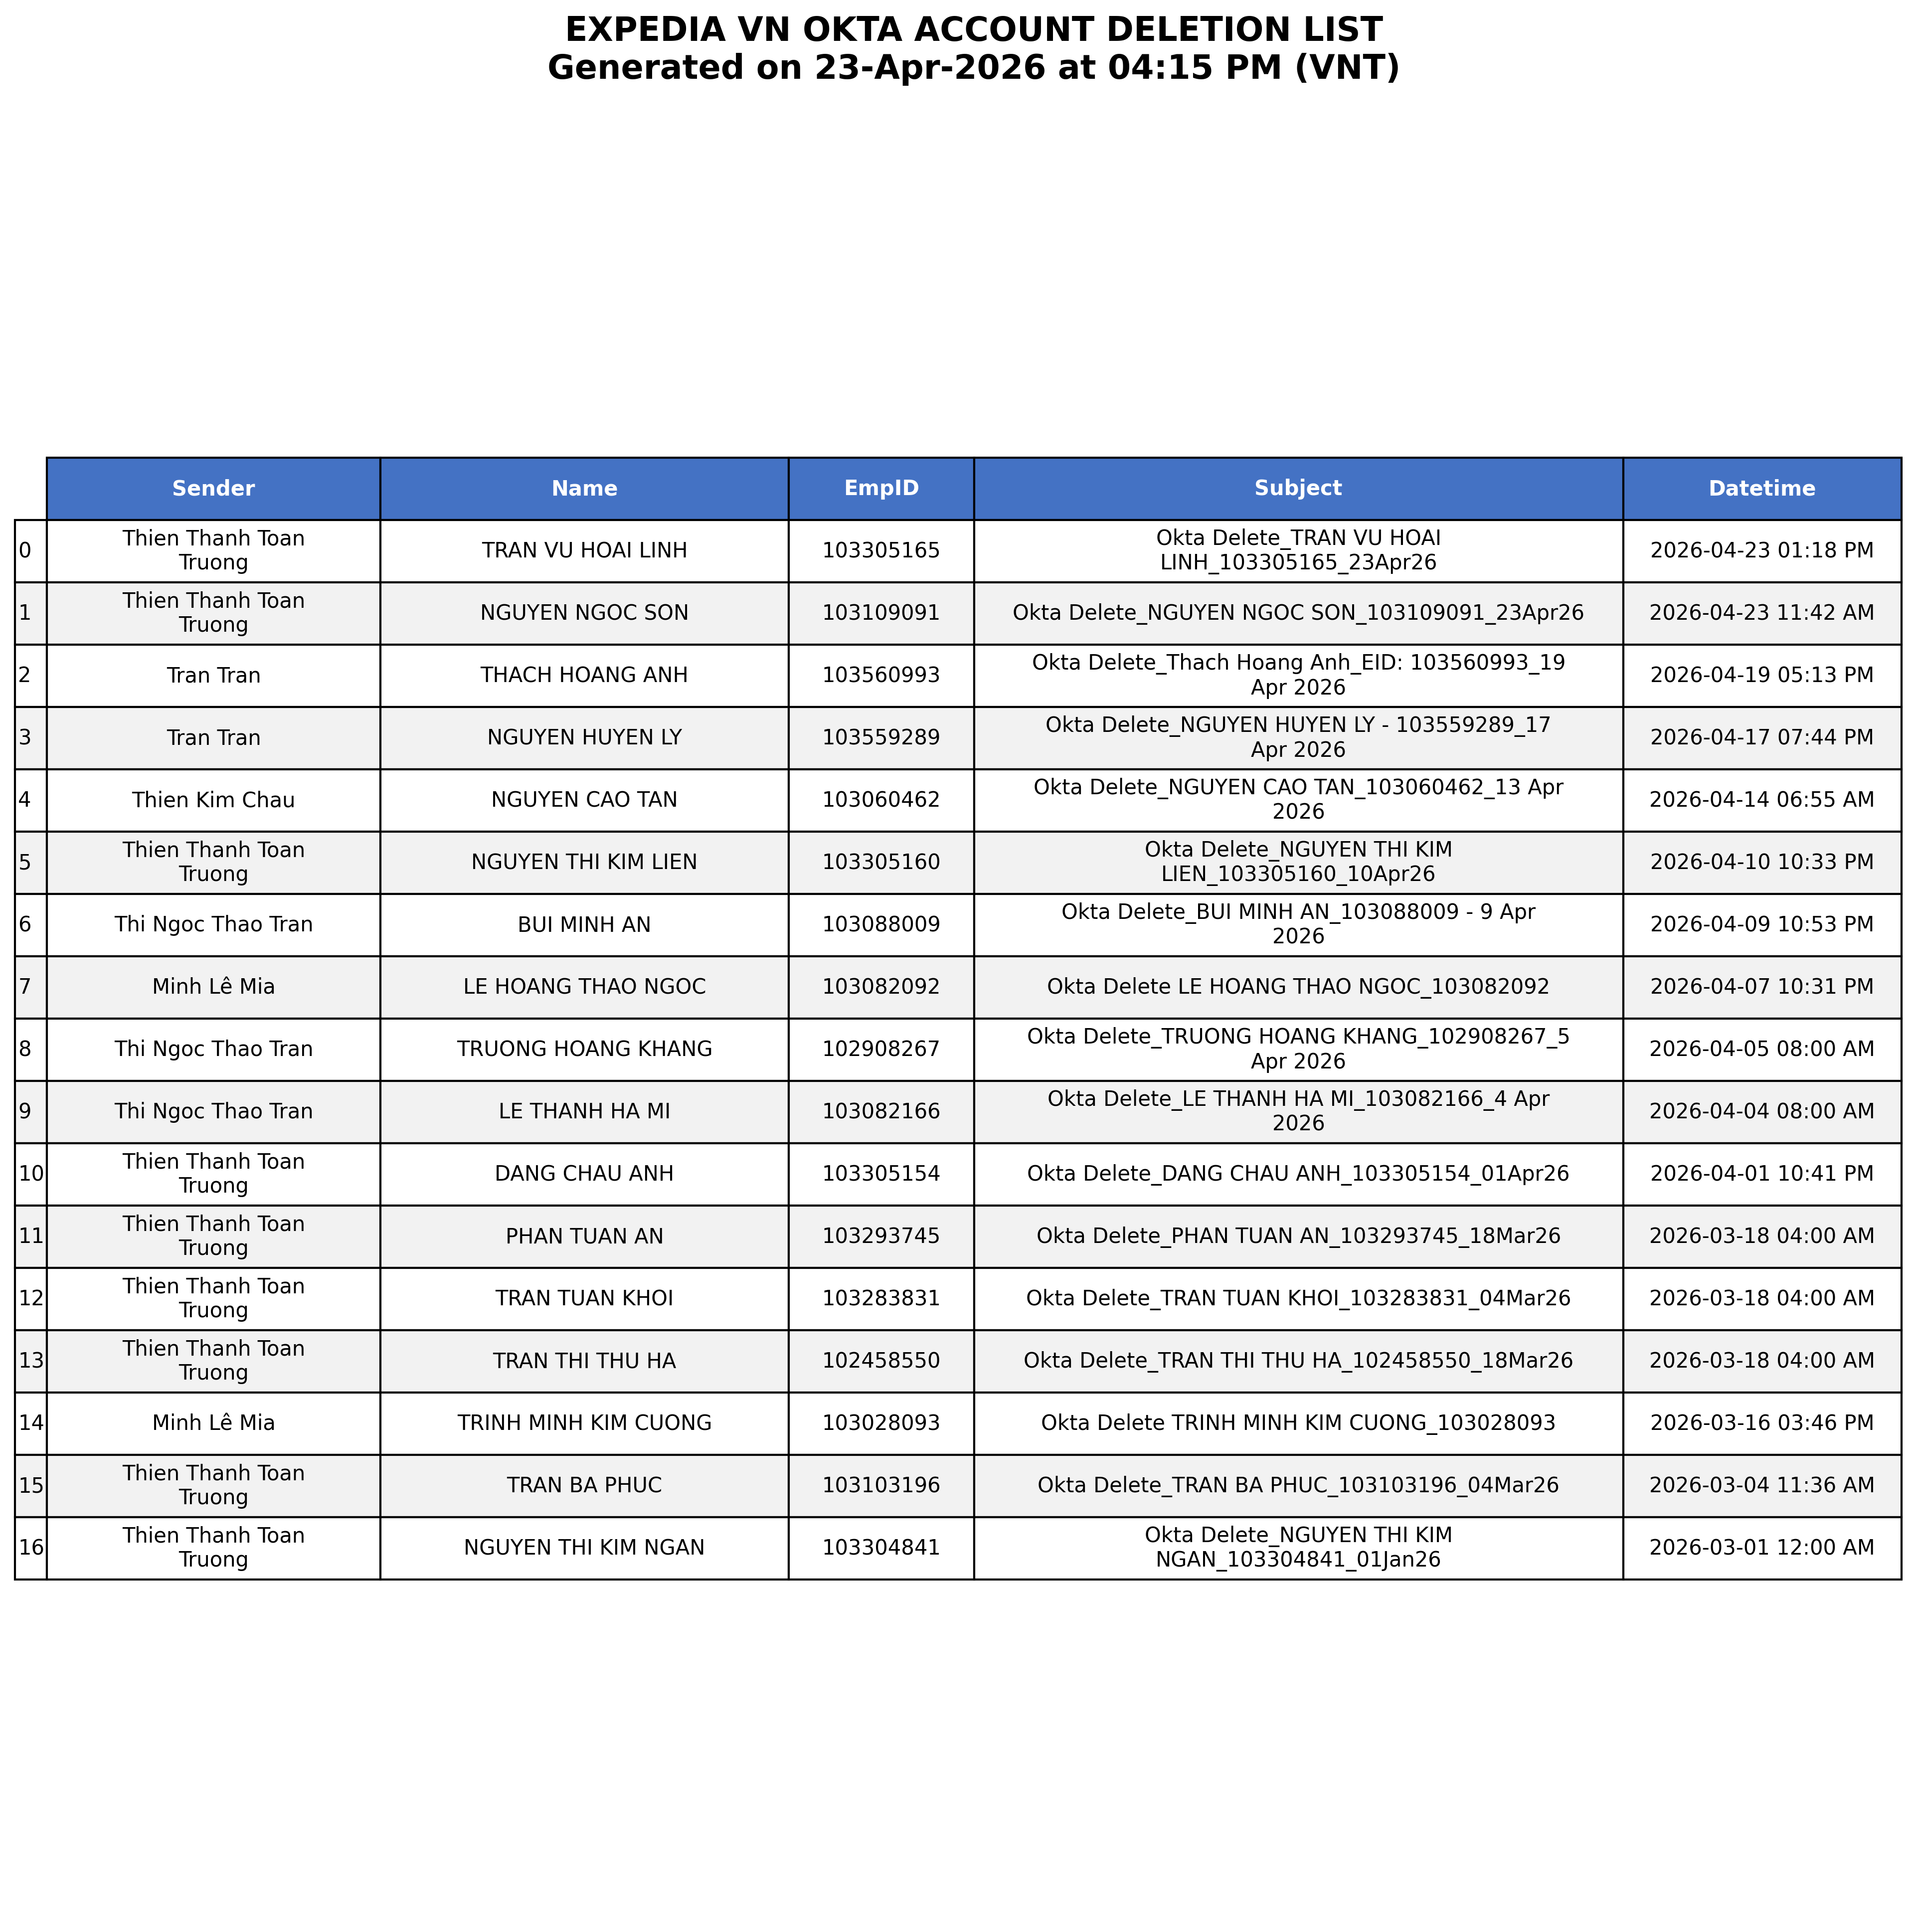

In [22]:
import matplotlib.pyplot as plt
from pandas.plotting import table
from PIL import Image
import io
import datetime
import textwrap
from IPython.display import display

if 'final_table' in locals() and not final_table.is_empty():
    pdf = final_table.to_pandas()
    
    pdf['Subject'] = pdf['Subject'].str.replace(TARGET_SUBJECT, "Okta Delete", regex=False)
    pdf['Subject'] = pdf['Subject'].apply(lambda x: textwrap.fill(str(x), width=45))
    pdf['Sender'] = pdf['Sender'].apply(lambda x: textwrap.fill(str(x), width=20))
    pdf['Datetime'] = pdf['Datetime'].dt.strftime("%Y-%m-%d %I:%M %p")

    fig_height = max(5, len(pdf) * 0.8 + 2) 
    fig, ax = plt.subplots(figsize=(16, fig_height))
    ax.axis('off')
    
    now = datetime.datetime.now()
    report_title = f'EXPEDIA VN OKTA ACCOUNT DELETION LIST\nGenerated on {now.strftime("%d-%b-%Y")} at {now.strftime("%I:%M %p")} (VNT)'
    ax.set_title(report_title, fontsize=16, fontweight='bold', loc='center', pad=20)
    
    tbl = table(ax, pdf, loc='center', cellLoc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1.0, 2.5) 

    col_widths = {
        'Sender': 0.18,
        'Name': 0.22,
        'EmpID': 0.10,
        'Subject': 0.35,
        'Datetime': 0.15
    }
    
    col_names = pdf.columns.tolist()
    for (row, col), cell in tbl.get_celld().items():
        if col >= 0:
            c_name = col_names[col]
            if c_name in col_widths:
                cell.set_width(col_widths[c_name])
        
        if row == 0:
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor('#4472C4')
        elif row > 0 and row % 2 == 0:
            cell.set_facecolor('#F2F2F2')
    
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', dpi=300)
    buf.seek(0)
    plt.close(fig)
    display(Image.open(buf))
else:
    print("No data to visualize.")